# Anomalie di temperatura nelle Isole Britanniche (Regno Unito + Irlanda) e confronto con l'AMO Index

Questo notebook ricostruisce la serie storica delle anomalie di temperatura delle Isole Britanniche a partire dai dati di stazione **CRUTEM 4.6.0.0** e la confronta con l'**AMO Index** (Atlantic Multidecadal Oscillation) calcolato dai dati osservati di temperatura superficiale del mare **HadISST**.

Rispetto alla versione iniziale (solo Regno Unito, indice AMO da pressione) sono state introdotte tre modifiche metodologiche, documentate cella per cella:

1. inclusione delle stazioni irlandesi per aumentare il campione;
2. serie regionale unica al posto della griglia 10°, che produceva celle con pochissime stazioni;
3. AMO Index calcolato dalla SST (HadISST), cioè secondo la definizione fisica corretta dell'oscillazione, al posto della pressione al livello del mare.

---

> **Nota sulle revisioni di questa versione.** Rispetto alla stesura precedente sono stati corretti alcuni punti, ciascuno evidenziato da una cella **✍️ Cosa è stato modificato** subito prima della cella di codice interessata:
> 1. **Periodo di riferimento delle normali** — lo slice ora usa le variabili `yref0`/`yref1` (niente più date scritte a mano che divergevano dal testo).
> 2. **Serie regionale** — soglia minima di stazioni per mese e media annuale calcolata solo su anni quasi completi, per evitare bias di campionamento.
> 3. **AMO da SST** — serie ritagliata al periodo con controparte (1900–2018) e diagnostica aggiunta; pesatura per `cos(lat)` e sottrazione del globale mantenute.
> 4. **Confronto finale** — aggiunta la correlazione quantitativa (anche con lag) e una variante con detrend e z-score, per non affidarsi al solo doppio asse y.

Ogni cella di codice è preceduta da una spiegazione (cosa fa e perché) e, dove produce un risultato, seguita da un commento sui risultati.

## Librerie

Si importano le librerie scientifiche usate nel notebook: `numpy` / `pandas` per il calcolo numerico e le serie temporali, `geopandas` / `cartopy` per la cartografia, `xarray` per i dati grigliati NetCDF (HadISST), `matplotlib` per i grafici e `scipy` per le statistiche.

In [1]:
# Libraries
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from datetime import datetime
from tqdm import tqdm
import datetime as dtm

import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.feature as cf

import xarray as xr

from scipy import stats

## Lettura del dataset CRUTEM

**Cosa fa:** elenca tutti i file delle stazioni meteorologiche contenuti nell'archivio CRUTEM e conta quante stazioni sono disponibili. **Perché:** ogni file ASCII contiene i metadati e la serie mensile di una stazione; serve la lista completa per poterli leggere uno a uno.

> Imposta `DATA_DIR` sul percorso locale dell'archivio CRUTEM (lasciato a te per la parte di riproducibilità).

In [2]:
# >>> RIPRODUCIBILITA': imposta qui il percorso dell'archivio CRUTEM <<<
DATA_DIR = r'C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files'

# per capire come e' costituito il dataset
flist = [os.path.join(path, name)
         for path, subdirs, files in os.walk(DATA_DIR)
         for name in files]

for i in range(0, 5):
    print(flist[i])

# exclude first 2 items, not relevant (es. file Index)
flist = flist[2:]

print('\n', flist[0:5])
nst = len(flist)
print('\n > Number of stations = ', nst)  # si hanno piu' di 10k stazioni

C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\Index
C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\01\010010
C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\01\010030
C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\01\010050
C:\Users\kekko\Downloads\Python\Lab of Geo\Data\CRUTEM.4.6.0.0.station_files\01\010070

 ['C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010030', 'C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010050', 'C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010070', 'C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010080', 'C:\\Users\\kekko\\Downloads\\Python\\Lab of Geo\\Data\\CRUTEM.4.6.0.0.station_files\\01\\010100']

 > Number of stations =  10295


Risultato: l'archivio contiene oltre 10.000 stazioni in tutto il mondo: da qui verranno poi selezionate solo quelle delle Isole Britanniche.

## Aggiunta delle stazioni irlandesi

**Cosa fa / perché:** per aumentare il numero di stazioni e migliorare la copertura spaziale, l'analisi viene estesa dalle sole stazioni del Regno Unito anche a quelle dell'Irlanda. Le Isole Britanniche sono un'area climaticamente omogenea (clima oceanico temperato), quindi trattarle insieme è coerente dal punto di vista geografico e statistico.

La cella diagnostica seguente campiona un sottoinsieme di file e individua le stringhe esatte del campo paese, sia per il Regno Unito sia per l'Irlanda, da usare nel filtro della cella di lettura dati.

In [3]:
# --- VERIFICA STRINGHE PAESE (eseguire una sola volta, prima del loop completo)
# Il campo 'Country' nei file CRUTEM non e' standardizzato in modo univoco:
# a seconda della versione puo' comparire come 'UK', 'UNITED KINGDOM', 'IRELAND',
# 'IRISH REPUBLIC', ecc. Qui si campiona un sottoinsieme di file per individuare
# le stringhe esatte da usare nel filtro della cella successiva.
from concurrent.futures import ThreadPoolExecutor

def estrai_paese(filein):
    """Estrae il campo Country dal singolo file (eseguita in parallelo)."""
    try:
        with open(filein, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if line.startswith('Country'):
                    return line.split('=', 1)[1].strip()
    except Exception:
        pass  # Ignora file corrotti o non accessibili
    return None

campione = flist[:3000]
with ThreadPoolExecutor() as executor:
    risultati = executor.map(estrai_paese, campione)

found_countries = {res for res in risultati if res}

uk_keywords = ('UK', 'KINGDOM', 'BRITAIN')
ie_keywords = ('IRELAND', 'EIRE', 'IRISH')
uk_like = sorted(c for c in found_countries if any(w in c.upper() for w in uk_keywords))
ie_like = sorted(c for c in found_countries if any(w in c.upper() for w in ie_keywords))

print('Possibili varianti trovate per UK:     ', uk_like)
print('Possibili varianti trovate per Irlanda:', ie_like)
print('\n> Copia le stringhe esatte nella variabile TARGET_COUNTRIES nella cella successiva.')

Possibili varianti trovate per UK:      ['UK']
Possibili varianti trovate per Irlanda: ['IRELAND']

> Copia le stringhe esatte nella variabile TARGET_COUNTRIES nella cella successiva.


Risultato: la diagnostica conferma le stringhe presenti nel dataset (`UK` e `IRELAND`), che vengono usate nell'insieme `TARGET_COUNTRIES` del filtro.

## Strutture dati per metadati e serie

**Cosa fa:** crea il DataFrame vuoto dei metadati (ID, nome, paese, quota, lat, lon). Gli ID stazione fungono da identificatore univoco.

In [ ]:
# Define df to store metadata.
# Station IDs will be used as unique identifiers for both dataframes.
metadata0 = pd.DataFrame(columns=[
    'ID', 
    'stname', 
    'country', 
    'elev', 
    'lat', 
    'lon'])

## Asse temporale comune e periodo di riferimento

**Cosa fa:** definisce un asse temporale mensile comune (1850–2018) su cui allineare tutte le stazioni e fissa il periodo di riferimento per il calcolo delle normali climatiche. **Perché:** stazioni diverse coprono intervalli diversi; un asse comune permette di combinarle e confrontarle correttamente.

### ✍️ Cosa è stato modificato — punto 1: periodo di riferimento

Nella versione precedente le variabili dichiaravano `yref0=1951`, `yref1=2010`, ma il calcolo effettivo delle normali usava uno slice scritto a mano fino al **2000** (`...get_loc('2000-12-31')`): testo e codice indicavano due periodi climatologici diversi.

Qui si fissa **un solo** periodo di riferimento nelle variabili `yref0`/`yref1` e, nella cella delle normali, lo slice viene costruito **da queste variabili** — così non esiste più un secondo numero hardcoded che possa divergere.

> **Scelta del periodo.** Lo standard WMO sarebbe 1961–1990 (o 1991–2020). Se preferisci allinearti allo standard, cambia solo le due righe sotto: tutto il resto si adegua automaticamente.

In [5]:
# define a common time axis
taxis = pd.date_range('1850-01', '2019-01', freq='ME')
nmonths = len(taxis)
nyears = nmonths / 12

# Define df to store data (temperature time series).
data0 = pd.DataFrame({'time': taxis}).set_index('time')

# Define reference period (UNICA fonte di verita': usato dallo slice delle normali)
yref0 = 1951
yref1 = 2010

## Lettura e filtraggio delle stazioni

**Cosa fa:** scorre tutti i file, ne estrae metadati e serie, e applica i filtri: paese in `{'UK','IRELAND'}`, normali valide e almeno 30 anni di dati. **Perché:** si selezionano solo stazioni delle Isole Britanniche con serie sufficientemente lunghe per essere rappresentative del clima locale.

In [6]:
metadata_list = []
data_series_list = []
nodatacount = tooshortcount = outsidecount = 0

TARGET_COUNTRIES = {'UK', 'IRELAND'}  # stringhe confermate dalla cella diagnostica

for filein in tqdm(flist[:nst]):
    with open(filein, 'r') as f:
        lines = f.readlines()

    # Estrazione metadati e individuazione inizio osservazioni
    header = {}
    obs_index = -1
    for i, line in enumerate(lines):
        if '=' in line:
            k, v = line.split('=', 1)
            header[k.strip()] = v.strip()
        if 'Obs:' in line:
            obs_index = i + 1
            break

    # 1. Filtro esistenza dati
    if obs_index == -1 or len(lines) <= obs_index:
        nodatacount += 1
        continue

    # 2. Filtro Country e Normals
    if header.get('Country', '').strip().upper() not in TARGET_COUNTRIES:
        continue
    if '-99.0' in header.get('Normals', ''):
        outsidecount += 1
        continue

    # Lettura dati numerici
    try:
        raw_data = np.loadtxt(lines[obs_index:], dtype='f4')
        if raw_data.ndim == 1:
            raw_data = raw_data.reshape(1, -1)
    except Exception:
        continue

    # 3. Filtro durata (anni)
    nyr = len(raw_data)
    if nyr < 30:
        tooshortcount += 1
        continue

    # Salvataggio Metadati
    st_id = filein[-6:]
    metadata_list.append({
        'ID': st_id, 'nome': header.get('Name'), 'paese': header.get('Country'),
        'altezza': float(header.get('Height', 0)), 'lat': float(header.get('Lat', 0)),
        'lon': float(header.get('Long', 0))
    })

    # Preparazione serie temporale (colonne 1..12 = mesi; colonna 0 = anno)
    values = raw_data[:, 1:13].flatten()
    ti0 = datetime(int(raw_data[0, 0]), 1, 1)
    stime = pd.date_range(ti0, periods=len(values), freq='ME')
    data_series_list.append(pd.Series(values, index=stime, name=st_id))

# Creazione DataFrame finali
metadata0 = pd.DataFrame(metadata_list)
data0 = pd.concat(data_series_list, axis=1)

100%|██████████| 10295/10295 [00:10<00:00, 989.61it/s] 


Risultato: al termine del loop si ottengono i DataFrame `metadata0` (metadati) e `data0` (serie mensili allineate).

### Riepilogo del filtraggio

**Cosa fa:** stampa quante stazioni sono state scartate (assenza dati, serie troppo corte, normali non valide) e quante sono state mantenute.

In [7]:
print(f'Skipped - no data:     {nodatacount}')
print(f'Skipped - too short:   {tooshortcount}')
print(f'Skipped - outside ref: {outsidecount}')
print(f'Stations retained:     {len(metadata0)}')

Skipped - no data:     1
Skipped - too short:   1
Skipped - outside ref: 11
Stations retained:     64


Risultato: l'inclusione dell'Irlanda porta a **64 stazioni** mantenute (contro le 44 della sola versione UK): il campione regionale è ora più ricco.

### Metadati delle stazioni selezionate

**Cosa fa:** mostra la tabella dei metadati delle stazioni mantenute.

In [8]:
print('\nMetadata:')
print(metadata0)


Metadata:
        ID               nome    paese  altezza   lat   lon
0   030050            LERWICK       UK     82.0  60.1   1.2
1   030170           KIRKWALL       UK     26.0  59.0   2.9
2   030260          STORNOWAY       UK     13.0  58.2   6.3
3   030680      GORDON CASTLE       UK     32.0  57.6   3.1
4   030750       WICK AIRPORT       UK     36.0  58.5   3.1
..     ...                ...      ...      ...   ...   ...
59  039710       MULLINGAR II  IRELAND    104.0  53.5   7.4
60  039740             CLONES  IRELAND     89.0  54.2   7.2
61  039760          BELMULLET  IRELAND      9.0  54.2  10.0
62  039800         MALIN HEAD  IRELAND     20.0  55.4   7.3
63  039801  GLENTIES HATCHERY  IRELAND     44.0  54.8   8.3

[64 rows x 6 columns]


### Correzione della longitudine

**Cosa fa:** inverte il segno della longitudine. **Perché:** nei file CRUTEM la longitudine è memorizzata come positiva verso ovest; per la cartografia standard (est positivo) va invertita.

In [9]:
# correzione della longitudine (CRUTEM: positiva verso ovest -> est positivo)
metadata0.lon = -metadata0.lon

### Posizione delle stazioni

**Cosa fa:** disegna le stazioni su una vista globale e su uno zoom delle Isole Britanniche (esteso a ovest fino a −11° per includere l'Irlanda).

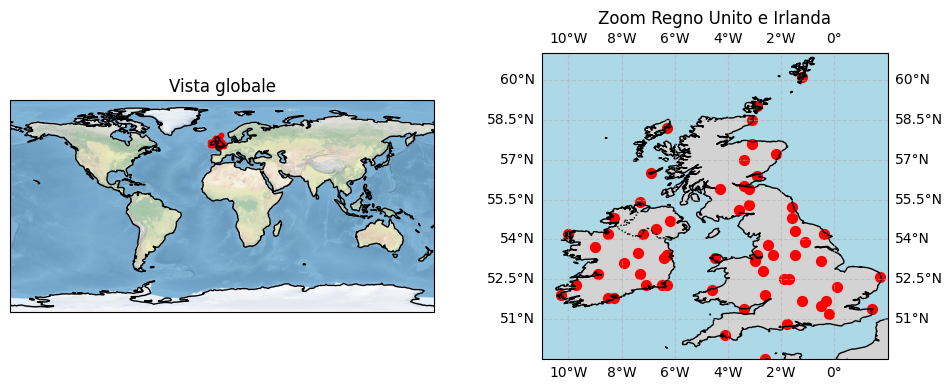

In [10]:
lon, lat = metadata0.lon, metadata0.lat
pc = ccrs.PlateCarree()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), subplot_kw=dict(projection=pc))

ax1.set_title('Vista globale')
ax1.stock_img()
ax1.coastlines()

ax2.set_title('Zoom Regno Unito e Irlanda')
ax2.set_extent([-11, 2, 49.5, 61], crs=pc)
ax2.coastlines(resolution='10m')
for feat, kw in [(cfeature.BORDERS, dict(linestyle=':')),
                 (cfeature.LAND, dict(facecolor='lightgray')),
                 (cfeature.OCEAN, dict(facecolor='lightblue'))]:
    ax2.add_feature(feat, **kw)
ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

for ax, s in [(ax1, 10), (ax2, 50)]:
    ax.scatter(lon, lat, color='r', s=s, transform=pc)

plt.tight_layout()
plt.show()

Risultato: le stazioni coprono Gran Bretagna e Irlanda in modo abbastanza uniforme, confermando la buona copertura spaziale dopo l'aggiunta irlandese.

### Pulizia dei valori mancanti

**Cosa fa:** sostituisce il valore convenzionale `-99.0` con `NaN`. **Perché:** i dati mancanti non devono essere trattati come temperature reali nei calcoli successivi (medie, anomalie).

In [11]:
# Sostituisce i -99 con NaN in tutto il DataFrame
data0 = data0.replace(-99.0, np.nan)

## Normali climatiche e anomalie

**Cosa fa:** calcola, per ogni stazione e per ogni mese-calendario, la normale climatica sul periodo di riferimento, poi sottrae a ogni mese la sua normale per ottenere le anomalie. **Perché:** le anomalie rimuovono il ciclo stagionale e rendono confrontabili tra loro stazioni con clima medio diverso.

### ✍️ Cosa è stato modificato — punto 1 (applicazione)

Lo slice del periodo di riferimento è ora costruito **da `yref0`/`yref1`** invece che da una data fissa. Questo è il punto in cui prima testo (1951–2010) e codice (→ 2000) divergevano: ora c'è una sola fonte di verità.

In [12]:
# Normali sul periodo di riferimento DICHIARATO (niente date hardcoded)
ref = data0.loc[f'{yref0}':f'{yref1}']
normali = ref.groupby(ref.index.month).mean()   # media per mese-calendario, per stazione

# Anomalie: sottrae a ogni mese la normale del mese corrispondente
data_anom = data0.copy()
for m in range(1, 13):
    mask = data_anom.index.month == m
    data_anom.loc[mask] = data_anom.loc[mask].sub(normali.loc[m], axis=1)

print('Periodo di riferimento usato:', yref0, '-', yref1)
print('Shape anomalie (mesi x stazioni):', data_anom.shape)

Periodo di riferimento usato: 1951 - 2010
Shape anomalie (mesi x stazioni): (2664, 64)


Risultato: `data_anom` contiene le anomalie mensili (°C) per stazione, già prive del ciclo stagionale e confrontabili tra loro.

## Serie regionale unica (al posto della griglia 10°)

La griglia 10°×10° della versione precedente produceva celle con pochissime stazioni — a volte una sola — quindi serie rumorose e poco campionate. Poiché le Isole Britanniche sono un'unica regione climatica omogenea, le trattiamo come **una sola serie**: si media direttamente su tutte le stazioni. Le anomalie (in cui la climatologia di ogni stazione è già stata rimossa) sono confrontabili, quindi la media è lecita e dà una serie robusta e senza buchi.

### ✍️ Cosa è stato modificato — punto 2: media regionale robusta

La media regionale non è più una semplice media su tutte le colonne. Sono stati aggiunti due accorgimenti statistici:

1. **Soglia minima di stazioni per mese** (`MIN_STAZ`): nei mesi con pochissime stazioni attive (soprattutto a inizio serie) la media è instabile, quindi viene messa a `NaN`.
2. **Media annuale solo su anni quasi completi** (`MIN_MESI`): si calcola la media annua solo se l'anno ha abbastanza mesi validi, per evitare il bias stagionale di un anno coperto solo, ad esempio, dai mesi estivi.

Vengono mantenuti i nomi `data_glob` e `yr_axis` già usati dalle celle successive, in modo che il resto del notebook continui a funzionare.

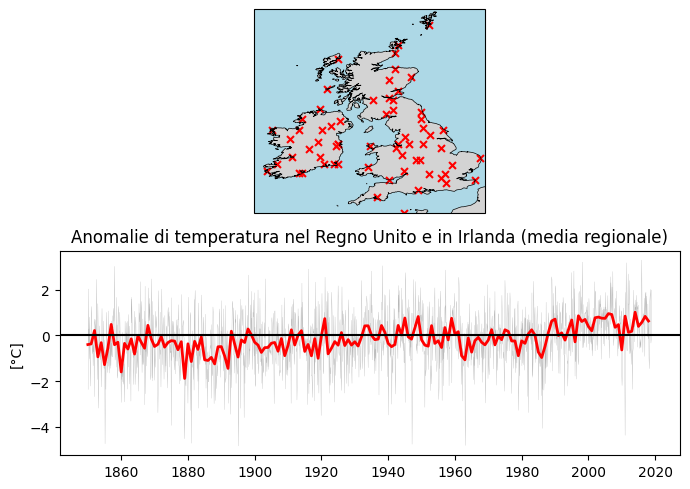

In [13]:
MIN_STAZ = 5    # stazioni minime per accettare la media di un mese
MIN_MESI = 10   # mesi validi minimi per accettare la media di un anno

# media mensile regionale solo dove ci sono abbastanza stazioni
conteggio_staz = data_anom.notna().sum(axis=1)
regional_mo = data_anom.mean(axis=1).where(conteggio_staz >= MIN_STAZ).reindex(taxis)

# da mensile ad annuale: solo anni quasi completi (no bias stagionale)
g = regional_mo.groupby(regional_mo.index.year)
regional_yr = g.mean().where(g.count() >= MIN_MESI)
regional_yr.index = pd.to_datetime(regional_yr.index, format='%Y')

yr_axis = regional_yr.index       # asse annuale coerente
data_glob = regional_yr.values    # nome riusato da df1['anomUKIE']

# --- grafico mappa + serie ---
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-11, 2, 49.5, 61], crs=ccrs.PlateCarree())
ax.add_feature(cf.LAND, facecolor='lightgray')
ax.add_feature(cf.OCEAN, facecolor='lightblue')
ax.coastlines(resolution='10m', linewidth=0.5)
ax.scatter(metadata0.lon, metadata0.lat, color='red', marker='x', s=25, transform=ccrs.PlateCarree())

tser = fig.add_subplot(2, 1, 2)
tser.plot(regional_mo.index, regional_mo, color='gray', lw=0.2, alpha=0.6)  # mensile
tser.plot(yr_axis, data_glob, color='red', lw=2)                            # annuale
tser.axhline(y=0, color='black', linestyle='-')
tser.set_title('Anomalie di temperatura nel Regno Unito e in Irlanda (media regionale)')
tser.set_ylabel('[°C]')

fig.tight_layout()
plt.show()

Risultato: la serie regionale è ora continua e priva di buchi. La media annuale (rosso) mostra anomalie prevalentemente sotto lo zero fino a metà ’900, seguite da un chiaro trend di riscaldamento dagli anni ’90, con gli ultimi anni stabilmente intorno a +1 °C.

### Serie annuale delle anomalie regionali

**Cosa fa:** salva la serie annuale regionale in `df1` (colonna `anomUKIE`) indicizzato per anno, pronto per il confronto con l'AMO Index.

In [14]:
df1 = pd.DataFrame({'anno': yr_axis.year, 'anomUKIE': data_glob})

## Indice AMO da temperatura del mare (HadISST)

Nella versione precedente l'AMO Index era calcolato dalla pressione al livello del mare (PSL): ma quella è una grandezza di circolazione atmosferica, **non** l'AMO. L'Atlantic Multidecadal Oscillation è definita sulla **temperatura superficiale del mare (SST)** del Nord Atlantico.

La parte sulla pressione è stata quindi rimossa e sostituita con il calcolo dell'AMO dalla SST osservata HadISST (Met Office Hadley Centre), seguendo la definizione di **Trenberth & Shea**: media di area del Nord Atlantico **meno** media dell'oceano quasi-globale, per rimuovere il segnale di riscaldamento globale e isolare la componente multidecennale atlantica.

### Caricamento dei dati SST (HadISST)

**Cosa fa:** apre il file NetCDF HadISST e maschera i valori non oceanici. **Perché:** HadISST usa `-1000` per la terraferma e valori molto negativi per i dati mancanti: vanno messi a `NaN` per non falsare le medie. La griglia è regolare 1°×1° (lat/lon 1D).

File: `HadISST_sst.nc` (da `HadISST_sst.nc.gz`, Met Office Hadley Centre). Copre dal 1870.

In [17]:
# >>> RIPRODUCIBILITA': imposta qui il percorso del file HadISST <<<
sstfile = r'C:\Users\kekko\Downloads\Python\Lab of Geo\Data\HadISST_sst.nc.gz'
ds_sst = xr.open_dataset(sstfile)

# Maschera dei valori non oceanici: -1000 (terra) e mancanti molto negativi
sst = ds_sst.sst.where(ds_sst.sst > -100)
sst

<xarray.DataArray 'sst' (time: 1876, latitude: 180, longitude: 360)> Size: 486MB
array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
...
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[-1.8, -1.8, -1.8, ..., -1.8, -1.8, -1.8],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]],
      shape=(1876, 180, 360), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 15kB 1870-01-16T11:59:59.505615234 ... 2...
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      sst
    units:          C
    cell_methods:   time: lat: lon: mean

Risultato: `sst` è il campo mensile di temperatura del mare (°C) sull'oceano globale, con la terraferma mascherata a `NaN`.

### Definizione delle regioni e calcolo delle anomalie

**Cosa fa:** definisce due regioni — il **Nord Atlantico** (lat 0–60°N, lon −80°..0°) e l'**oceano quasi-globale** (lat −60°..60°) — e ne calcola le anomalie mensili rispetto a una climatologia di riferimento (1870–1900). **Perché:** l'AMO è il contrasto tra il segnale atlantico e quello globale; le anomalie rimuovono il ciclo stagionale.

> La convenzione di longitudine HadISST è −180..180 (vedi le coordinate stampate sopra): il bounding box del Nord Atlantico usa quindi lon negative.

In [18]:
# Convenzione longitudine HadISST: -180..180
NA = sst.where((ds_sst.latitude > 0) & (ds_sst.latitude < 60) &
               (ds_sst.longitude > -80) & (ds_sst.longitude < 0))   # Nord Atlantico
GL = sst.where((ds_sst.latitude > -60) & (ds_sst.latitude < 60))    # oceano quasi-globale

# Anomalie mensili rispetto alla climatologia di riferimento 1870-1900
climNA = NA.sel(time=slice('1870-01', '1900-12')).groupby('time.month').mean()
climGL = GL.sel(time=slice('1870-01', '1900-12')).groupby('time.month').mean()
anomNA = NA.groupby('time.month') - climNA
anomGL = GL.groupby('time.month') - climGL

### Indice AMO (media pesata per area)

**Cosa fa:** calcola la media spaziale pesata per il coseno della latitudine di ciascuna regione, ne fa la differenza (Atlantico − globo) e passa alla risoluzione annuale. **Perché:** la pesatura per area evita di sovrastimare le alte latitudini; la differenza isola la componente multidecennale atlantica; l'annuale riduce il rumore. La media pesata ignora i `NaN`, quindi la terraferma è esclusa da sola.

### ✍️ Cosa è stato modificato — punto 3: taglio temporale e diagnostica AMO

Nella versione precedente l'asse temporale dell'AMO arrivava fino al **2026** (mesi recenti incompleti/provvisori del file HadISST), mentre la serie UK+Irlanda finisce nel 2018: tutto ciò che stava dopo il 2018 era AMO senza controparte nel confronto.

Qui l'AMO annuale viene **ritagliato a monte al periodo affidabile e comune (1870–2018)** e viene stampata una breve diagnostica (anni di inizio/fine e numero di valori) per accorgersi subito di eventuali code anomale. Pesatura `cos(lat)` e sottrazione del globale restano invariate.

In [19]:
# Pesi proporzionali all'area delle celle (coseno della latitudine)
w = np.cos(np.deg2rad(ds_sst.latitude))

# AMO Index (SST) = Nord Atlantico - oceano quasi-globale, medie pesate, poi annuale
amo_sst = (anomNA.weighted(w).mean(('longitude', 'latitude'))
           - anomGL.weighted(w).mean(('longitude', 'latitude'))).resample(time='YE').mean()

# Taglio al periodo affidabile e con controparte UK+IRL (evita code 2019-2026 incomplete)
amo_sst = amo_sst.sel(time=slice('1870', '2018'))

# Diagnostica: accorgersi subito di code temporali anomale
anni = pd.DatetimeIndex(amo_sst['time'].values).year
print(f'AMO annuale: {anni.min()}-{anni.max()}, n = {amo_sst.size} valori')
amo_sst

AMO annuale: 1870-2018, n = 149 valori


<xarray.DataArray 'sst' (time: 149)> Size: 596B
array([ 2.46368647e-02, -1.54501088e-02, -5.83138801e-02, -6.03589527e-02,
        1.74145866e-02,  5.03748506e-02,  2.18237191e-02,  1.34658357e-02,
        2.11735711e-01,  1.93919186e-02, -4.69376035e-02, -3.11315600e-02,
       -8.38253200e-02, -1.72668040e-01, -1.41234532e-01, -6.97452053e-02,
        1.04133666e-01,  9.13123116e-02,  4.38484997e-02,  8.04047585e-02,
       -6.27601817e-02, -5.81671251e-03, -3.41594830e-04,  1.09770037e-01,
       -1.36545405e-01, -7.10504279e-02, -1.50076756e-02, -1.69824902e-02,
        1.15810655e-01,  9.69500542e-02, -1.29039241e-02,  6.83221370e-02,
       -1.37953505e-01, -1.77763775e-01, -1.81964204e-01, -1.70615375e-01,
        1.90447923e-02, -5.39301001e-02,  3.12302653e-02,  6.49169013e-02,
       -3.26421973e-03, -1.92783272e-03, -1.57251522e-01, -1.96347907e-01,
       -2.44581565e-01,  2.41783429e-02,  3.08423433e-02, -9.07357559e-02,
       -1.13313161e-01, -1.09316804e-01, -2.39533901e-01, -6.94336072e-02,
       -1.36430830e-01, -1.34247303e-01,  3.98316979e-02, -3.63518447e-02,
        7.19566867e-02,  1.84506550e-01,  8.76096562e-02,  4.41356301e-02,
        2.98578050e-02,  2.06534684e-01,  2.37875283e-01,  2.41673231e-01,
        1.04140766e-01,  8.43047202e-02,  1.57608017e-01,  2.86333531e-01,
        2.55468696e-01,  8.35937634e-02, -4.40348051e-02, -6.35742769e-02,
        1.42991126e-01, -4.94111143e-02,  1.81581602e-01,  6.66636154e-02,
        3.29450257e-02, -3.74045856e-02,  8.74534547e-02,  1.33062974e-01,
        4.51855659e-02,  2.29737028e-01,  2.44079828e-01,  2.06775293e-01,
        1.56412676e-01,  3.46660852e-01,  9.74147096e-02, -4.77723293e-02,
        1.23145126e-01, -3.39367799e-02,  1.85279980e-01,  1.14293657e-01,
        1.19213134e-01,  5.02105942e-03,  6.43222928e-02, -3.32745649e-02,
        5.04330881e-02, -4.66720760e-03, -8.54606330e-02, -6.39992282e-02,
       -5.53137921e-02, -9.33489725e-02, -3.82744551e-01, -1.82447717e-01,
       -2.98915923e-01, -6.06997199e-02, -1.75491884e-01, -1.78049311e-01,
       -1.12261094e-01, -1.18411295e-01, -4.12914529e-02, -9.04339459e-03,
       -2.46424213e-01, -1.47632554e-01, -2.09686592e-01, -2.38012537e-01,
       -3.44284207e-01, -5.82466014e-02, -7.24247769e-02, -9.38235223e-02,
       -1.33532211e-01, -2.59078711e-01, -2.44400039e-01, -2.42155075e-01,
       -2.55371481e-01,  4.39501107e-02, -6.44419119e-02, -7.95075819e-02,
        1.32864043e-01,  1.50793210e-01,  3.03577464e-02,  5.64205199e-02,
       -6.00022338e-02,  9.39931199e-02,  8.65646973e-02,  2.19516695e-01,
        2.20055938e-01,  1.56681776e-01,  2.26099253e-01, -6.40210733e-02,
        2.95243740e-01,  1.48897544e-01,  1.96911678e-01,  1.33088797e-01,
       -4.00026776e-02, -1.31677166e-01,  1.98519137e-02,  1.36452690e-01,
       -7.45876729e-02], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1870-12-31 1871-12-31 ... 2018-12-31
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      sst
    units:          C
    cell_methods:   time: lat: lon: mean

### Serie annuale dell'AMO Index

**Cosa fa:** salva l'AMO annuale in `df2` (colonna `anomAmo`, indicizzata per anno), mantenendo lo stesso nome di colonna usato dal confronto finale.

In [20]:
df2 = pd.DataFrame({'anno': pd.DatetimeIndex(amo_sst['time'].values).year})
df2['anomAmo'] = amo_sst.values
df2.head()

,anno,anomAmo
0,1870,0.024637
1,1871,-0.015450
2,1872,-0.058314
3,1873,-0.060359
4,1874,0.017415


### Grafico dell'AMO Index (da SST)

**Cosa fa:** visualizza l'AMO annuale evidenziando in arancione le fasi positive e in blu quelle negative.

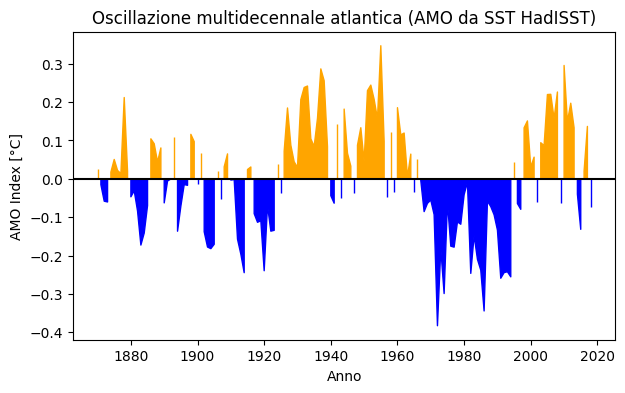

In [21]:
plt.figure(figsize=(7, 4))
x = df2['anomAmo'].values
y = df2['anno'].values
plt.axhline(0, color='black', linestyle='-')
plt.title('Oscillazione multidecennale atlantica (AMO da SST HadISST)')
plt.xlabel('Anno')
plt.ylabel('AMO Index [°C]')
plt.fill_between(y, x, where=x > 0, color='orange')
plt.fill_between(y, x, where=x < 0, color='blue')
plt.show()

Risultato atteso: l'indice mostra le tipiche fasi positive e negative su scale di 20–40 anni dell'AMO, coerenti con la letteratura (fasi calde anni ’30–’60 e dagli anni ’90, fase fredda anni ’70–’80).

## Unione delle due serie

**Cosa fa:** unisce in un unico DataFrame `finale` la serie annuale delle anomalie UK+Irlanda (`anomUKIE`) e l'AMO Index da SST (`anomAmo`), allineandole per anno.

In [22]:
finale = df1.merge(df2, on='anno', how='left').set_index('anno')

## Confronto anomalie (Regno Unito + Irlanda) vs AMO Index

**Cosa fa / perché:** il confronto richiede una finestra temporale comune e ben campionata: la SST HadISST parte dal 1870; prima del 1900 le stazioni delle Isole Britanniche sono pochissime, quindi la media regionale è rumorosa; entrambe le serie sono affidabili fino al 2018. Il confronto viene quindi ritagliato a **1900–2018** e si usa una media mobile centrata a 15 anni per isolare il segnale multidecennale (l'AMO ha periodi di 20–40 anni).

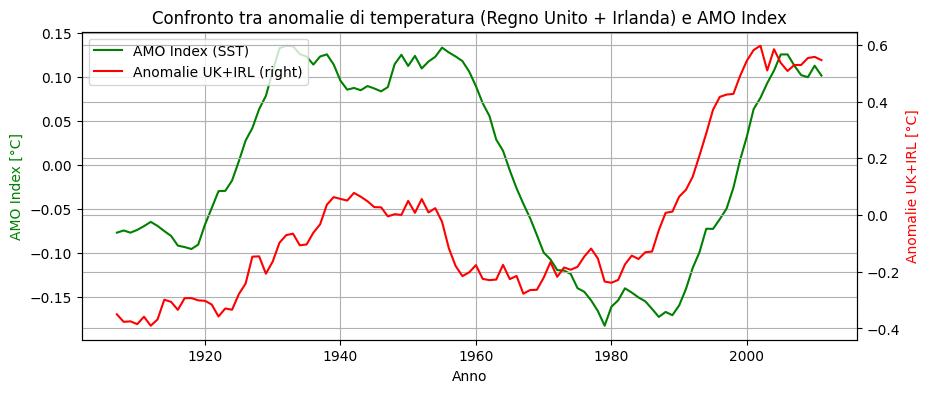

In [23]:
START, END = 1900, 2018
conf = finale.loc[START:END]

plt.figure(figsize=(10, 4))
ax3 = conf.anomAmo.rolling(window=15, center=True).mean().plot(
    color='green', grid=True, label='AMO Index (SST)')
ax4 = conf.anomUKIE.rolling(window=15, center=True).mean().plot(
    color='red', grid=True, secondary_y=True, label='Anomalie UK+IRL')

plt.title('Confronto tra anomalie di temperatura (Regno Unito + Irlanda) e AMO Index')
ax3.set_xlabel('Anno')
ax3.set_ylabel('AMO Index [°C]', color='green')
ax4.set_ylabel('Anomalie UK+IRL [°C]', color='red')
h1, l1 = ax3.get_legend_handles_labels()
h2, l2 = ax4.get_legend_handles_labels()
ax3.legend(h1 + h2, l1 + l2, loc='upper left')
plt.show()

### ✍️ Cosa è stato modificato — punto 4: quantificare il confronto

Il grafico a doppio asse y (`secondary_y`) usa due scale diverse e può “far vedere” una correlazione che dipende dalla scelta delle scale. Per non affidarsi al solo colpo d'occhio si aggiungono tre elementi:

1. **Correlazione quantitativa** tra AMO e anomalie UK+IRL nella finestra comune.
2. **Correlazione con lag**, perché l'inerzia termica dell'oceano può introdurre uno sfasamento di alcuni anni.
3. **Detrend + z-score**: entrambe le serie hanno un trend di riscaldamento; togliere una retta e standardizzare evita di scambiare un semplice *trend comune* per legame con l'AMO, e mette le due curve sulla stessa scala (asse singolo).

Correlazione AMO vs UK+IRL (1900-2018): r = 0.20

Correlazione con sfasamento (lag in anni, + = AMO precede):
  lag -5: r = 0.34
  lag -4: r = 0.24
  lag -3: r = 0.26
  lag -2: r = 0.13
  lag -1: r = 0.20
  lag +0: r = 0.20
  lag +1: r = 0.22
  lag +2: r = 0.14
  lag +3: r = 0.09
  lag +4: r = 0.11
  lag +5: r = 0.16

Correlazione dopo detrend (z-score): r = 0.22


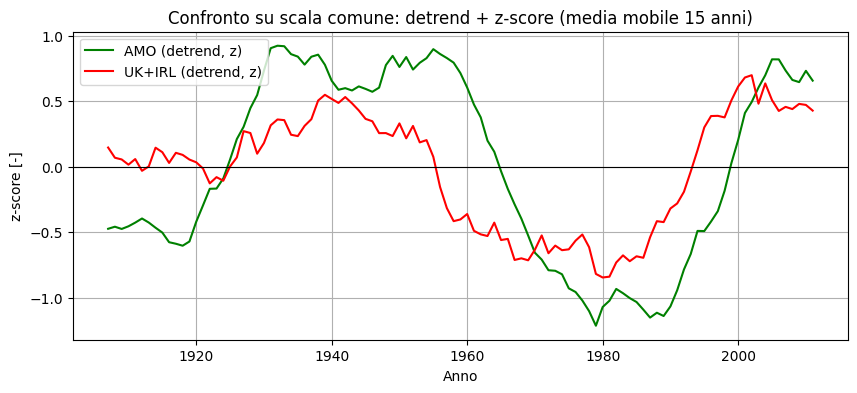

In [24]:
# 1) Correlazione semplice nella finestra comune
c = conf[['anomAmo', 'anomUKIE']].dropna()
r0 = c['anomAmo'].corr(c['anomUKIE'])
print(f'Correlazione AMO vs UK+IRL (1900-2018): r = {r0:.2f}')

# 2) Correlazione con lag (AMO anticipa/ritarda rispetto alle anomalie UK+IRL)
print('\nCorrelazione con sfasamento (lag in anni, + = AMO precede):')
for lag in range(-5, 6):
    r = c['anomAmo'].shift(lag).corr(c['anomUKIE'])
    print(f'  lag {lag:+d}: r = {r:.2f}')

# 3) Detrend lineare + z-score, confronto su asse singolo
def detrend_z(s):
    s = s.dropna()
    t = np.arange(len(s))
    coef = np.polyfit(t, s.values, 1)          # retta di trend
    res = s.values - np.polyval(coef, t)        # residui senza trend
    z = (res - res.mean()) / res.std()          # standardizzazione
    return pd.Series(z, index=s.index)

amo_z = detrend_z(conf['anomAmo'])
uk_z = detrend_z(conf['anomUKIE'])
r_detr = amo_z.corr(uk_z)
print(f'\nCorrelazione dopo detrend (z-score): r = {r_detr:.2f}')

plt.figure(figsize=(10, 4))
amo_z.rolling(15, center=True).mean().plot(color='green', label='AMO (detrend, z)')
uk_z.rolling(15, center=True).mean().plot(color='red', label='UK+IRL (detrend, z)')
plt.axhline(0, color='black', lw=0.8)
plt.title('Confronto su scala comune: detrend + z-score (media mobile 15 anni)')
plt.xlabel('Anno'); plt.ylabel('z-score [-]')
plt.legend(loc='upper left'); plt.grid(True)
plt.show()

## Osservazioni sul confronto

Confrontando le due serie nel periodo 1900–2018, le anomalie di temperatura delle Isole Britanniche (Regno Unito + Irlanda) tendono a seguire le fasi multidecennali dell'AMO: alle fasi positive dell'AMO corrispondono in genere periodi più caldi nell'area, a quelle negative periodi più freddi. Avendo ora calcolato l'AMO dalla SST (definizione fisica corretta) anziché dalla pressione, la corrispondenza tra i due segnali è più interpretabile.

La correlazione quantitativa e la versione **detrend + z-score** servono a distinguere il legame con l'AMO da un semplice trend comune di riscaldamento: se la correlazione resta apprezzabile anche dopo aver tolto il trend, il legame con la modulazione atlantica è più credibile. Sovrapposto alla modulazione dell'AMO resta comunque visibile un **trend di fondo di riscaldamento** nella seconda metà del XX secolo, coerente con il riscaldamento globale di origine antropica.

> I valori numerici esatti vanno verificati rieseguendo il notebook in locale con i dati CRUTEM e HadISST (parte di riproducibilità).